**STAGE 2 FACIAL RECOGNITION PROJECT (DO NOT RERUN)**

**Installing InsightFace and ONNX Runtime**

In [ ]:
!pip install -q -U insightface onnxruntime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 439.5/439.5 kB 9.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 97.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 116.8 MB/s eta 0:00:00


** Imports libraries and initializes the InsightFace ArcFace model (buffalo_l) on CPU.**

In [ ]:
import os
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from collections import Counter

import insightface
from insightface.app import FaceAnalysis

print("InsightFace version:", insightface.__version__)

app = FaceAnalysis(
    name="buffalo_l",
    providers=["CPUExecutionProvider"]
)
app.prepare(ctx_id=-1, det_size=(640, 640))

print("InsightFace loaded successfully.")

InsightFace version: 0.7.3
download_path: /root/.insightface/models/buffalo_l


100%|██████████| 281857/281857 [00:02<00:00, 113152.04KB/s]


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)
InsightFace 

**Walks through Gallery and Probe folders, detects faces in each image, and extracts 512-dimensional ArcFace embeddings.**

Below is 4 for ArcFace, if you can, please dont rerun this cell as it will take a long time


In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm

# paths
base_path = '/content/drive/MyDrive/DS_NN_Project_Pictures'
folders = ['Gallery ', 'Probe']

# store embeddings
arcface_data = {'Gallery ': [], 'Probe': []}

# collect all image paths first so we can track progress
image_tasks = []
for folder in folders:
    folder_path = os.path.join(base_path, folder)
    if not os.path.exists(folder_path):
        continue
    for root, _, files in os.walk(folder_path):
        for img_name in files:
            if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                image_tasks.append((folder, root, img_name))

print(f"Total images to process: {len(image_tasks)}")

# process each image with a progress bar
for folder, root, img_name in tqdm(image_tasks, desc="Extracting faces"):
    img_path = os.path.join(root, img_name)

    # read image
    img = cv2.imread(img_path)
    if img is None:
        continue

    # detect and extract face features
    faces = app.get(img)

    # check if at least one face is detected
    if len(faces) > 0:
        # get 512-d embedding
        embedding = faces[0].embedding
        # store filename, identity (folder name), and embedding
        identity = os.path.basename(root)
        arcface_data[folder].append({'filename': img_name, 'identity': identity, 'embedding': embedding})

print(f"\nExtracted {len(arcface_data['Gallery '])} embeddings from Gallery")
print(f"Extracted {len(arcface_data['Probe'])} embeddings from Probe")


Total images to process: 566


Extracting faces: 100%|██████████| 566/566 [05:51<00:00,  1.61it/s]


Extracted 95 embeddings from Gallery
Extracted 455 embeddings from Probe


**Loads VGG19 pretrained on ImageNet, uses InsightFace bounding boxes to crop faces, then extracts 4096-dimensional features from the fc2 layer.**

Below is 5 for VGG19, if you can, please dont rerun this cell as it will take a long time


In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm
from tensorflow.keras.applications.vgg19 import VGG19, preprocess_input
from tensorflow.keras.models import Model

# 1. Load VGG19 and create a model that outputs the 4096-d 'fc2' layer
base_model = VGG19(weights='imagenet', include_top=True)
vgg19_extractor = Model(inputs=base_model.input, outputs=base_model.get_layer('fc2').output)

print("VGG19 feature extractor loaded.")

vgg19_data = {'Gallery ': [], 'Probe': []}

# 2. Re-use image_tasks from the previous step
for folder, root, img_name in tqdm(image_tasks, desc="Extracting VGG19 features"):
    img_path = os.path.join(root, img_name)
    img = cv2.imread(img_path)
    if img is None:
        continue

    # Use InsightFace purely for consistent face detection (bounding box)
    faces = app.get(img)

    if len(faces) > 0:
        # Get bounding box coordinates for the first face
        bbox = faces[0].bbox.astype(int)
        x1, y1, x2, y2 = bbox

        # Ensure coordinates are within image boundaries
        x1 = max(0, x1)
        y1 = max(0, y1)
        x2 = min(img.shape[1], x2)
        y2 = min(img.shape[0], y2)

        # Crop the face
        face_crop = img[y1:y2, x1:x2]

        # Skip if crop is invalid or too small
        if face_crop.size == 0 or face_crop.shape[0] == 0 or face_crop.shape[1] == 0:
            continue

        # Convert BGR (OpenCV) to RGB (expected by Keras VGG19)
        face_rgb = cv2.cvtColor(face_crop, cv2.COLOR_BGR2RGB)

        # Resize to 224x224 for VGG19
        face_resized = cv2.resize(face_rgb, (224, 224))

        # Preprocess input (expand dims to create batch of 1, then apply VGG19 prep)
        x = np.expand_dims(face_resized, axis=0)
        x = preprocess_input(x)

        # Extract 4096-d features (verbose=0 to prevent printing every prediction)
        features = vgg19_extractor.predict(x, verbose=0)

        identity = os.path.basename(root)
        vgg19_data[folder].append({
            'filename': img_name,
            'identity': identity,
            'embedding': features[0]  # The 4096-d vector
        })

print(f"\nExtracted {len(vgg19_data['Gallery '])} VGG19 embeddings from Gallery")
print(f"Extracted {len(vgg19_data['Probe'])} VGG19 embeddings from Probe")

574710816/574710816 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
VGG19 feature extractor loaded.


Extracting VGG19 features: 100%|██████████| 566/566 [03:53<00:00,  2.43it/s]


Extracted 95 VGG19 embeddings from Gallery
Extracted 455 VGG19 embeddings from Probe


**Scans the dataset folder structure and lists all subfolders that contain images.**

In [ ]:
import os

base_path = '/content/drive/MyDrive/DS_NN_Project_Pictures'
folders = ['Gallery ', 'Probe']

# Dictionary to hold explicit paths to subfolders containing images
image_directories = {'Gallery ': [], 'Probe': []}

for folder in folders:
    folder_path = os.path.join(base_path, folder)
    if not os.path.exists(folder_path):
        print(f"Path not found: {folder_path}")
        continue

    # Walk through directory to find all explicit subfolder paths
    for root, dirs, files in os.walk(folder_path):
        # Filter for image files to ensure we only save useful paths
        image_files = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if len(image_files) > 0:
            image_directories[folder].append(root)

print(f"Found {len(image_directories['Gallery '])} explicit subfolders in Gallery.")
for path in image_directories['Gallery '][:5]:
    print(f" - {path}")
if len(image_directories['Gallery ']) > 5:
    print("   ...")

print(f"\nFound {len(image_directories['Probe'])} explicit subfolders in Probe.")
for path in image_directories['Probe'][:5]:
    print(f" - {path}")
if len(image_directories['Probe']) > 5:
    print("   ...")


Found 9 explicit subfolders in Gallery.
 - /content/drive/MyDrive/DS_NN_Project_Pictures/Gallery /willGallery
 - /content/drive/MyDrive/DS_NN_Project_Pictures/Gallery /tomcruiseGallery
 - /content/drive/MyDrive/DS_NN_Project_Pictures/Gallery /nicoGallery
 - /content/drive/MyDrive/DS_NN_Project_Pictures/Gallery /jackGallery
 - /content/drive/MyDrive/DS_NN_Project_Pictures/Gallery /KimGallery
   ...

Found 58 explicit subfolders in Probe.
 - /content/drive/MyDrive/DS_NN_Project_Pictures/Probe/willProbe/willExpression
 - /content/drive/MyDrive/DS_NN_Project_Pictures/Probe/willProbe/willOcclusion
 - /content/drive/MyDrive/DS_NN_Project_Pictures/Probe/willProbe/willLighting
 - /content/drive/MyDrive/DS_NN_Project_Pictures/Probe/willProbe/willSide
 - /content/drive/MyDrive/DS_NN_Project_Pictures/Probe/tomcruiseProbe/cruiseExpression
   ...


**Mounts Google Drive to access the project image folder in Colab.**

In [ ]:
from google.colab import drive


drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Verifies the dataset folder exists in Drive and previews its contents.**

In [ ]:
import os

# Define the path to your folder (assuming it's in the root of your MyDrive)
folder_path = '/content/drive/MyDrive/DS_NN_Project_Pictures'

# Check if the folder exists and list its contents
if os.path.exists(folder_path):
    print(f"Folder found! Listing contents of {folder_path}:")
    files = os.listdir(folder_path)
    for f in files[:10]: # Print first 10 files
        print(" -", f)
    if len(files) > 10:
        print(f"... and {len(files) - 10} more files.")
else:
    print(f"Folder NOT found at {folder_path}. Please check the path or ensure the folder name is exactly correct.")

Folder found! Listing contents of /content/drive/MyDrive/DS_NN_Project_Pictures:
 - Gallery 
 - Probe


**Re-initializes the ArcFace model with GPU support if available.**

In [ ]:
# init ArcFace model (downloads buffalo_l on first run)
app = FaceAnalysis(name='buffalo_l', providers=['CUDAExecutionProvider', 'CPUExecutionProvider'])
app.prepare(ctx_id=-1, det_size=(640, 640))
print('ArcFace model ready')

/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)
ArcFace mode

**Model Architectures and Feature Representations**

VGG19 is a deep neural network that was originally esigned for general image classification on the ImageNet dataset. Its architecture has 16 convolutional layers organized into five sequentail blocks, and then it has three fully connected layers and a final softmax classifier. For this project, VGG19 is used as a feature extractor, and the final softmax layer is removed and the output of the fc2 layer is taken as our feature vectors. Which is 4096 numbers per image. Since VGG 19 was trained on ImageNet rather than faces, the features encode general visual characterstics such as texture and shape but are not identity specific. VGG19 also doesnot detect or align faces internally, so images much be manually cropped.

**ArcFace**
ArcFace is a facial recognition model built specifically for identities. It runs on ResNet-50, which is a 50-layer network that uses residual skip connections to train effectively. It is trained with additive angular margin loss, which uses the angles between embeddings in a normalized hypersphere. this loss pulls same-identity embeddings together and pushes different ones apart. Each face is converted into 512-dimental L2-normalized embeddings.

**Comparison**
In comparing the two, VGG19's output is a generic visual descriptor from a network not trained on faces, which ArcFace's 512-dimentional output is a purpose-built identity descriptor from a network trained end-to-end on facial separation. Thus, we can expect ArcFace to product more separable clusters per identity than VGG19.





**Insight Face Pipeline**
InsightFace's FaceAnalysis class exposes a single get() method that runs three steps. The first is **Detection**: A RetinaFace model scans the input image at multiple scales and returns a bounded box and five facial landmarks for each detected face, which are the two eye centers, the nose tip, and two mouth corners. Next is **ALIGNMENT**: Using the landmarks, InsightFace computse an affine transformation that warps the face into a 112x112 pose. This makes sure that the eyes, nose, and mouth land in consistent pixel positions across all images. Without this step, differences in head pose or framing could introduce unhelpful variations. Lastly, we have **EMBEDDING** The aligned 112x112 face is passed through the ArcFace ResNet-50 model, which produces the final 512 dimentional L2-normalized embedding. All of these creates a very streamlined pipeline than VGG 19.

**Extracting and Saving Embeddings**
For each processed image, a structured record is saved containing the image filename, identity label, probe condition (or "clean" for gallery images), dataset split, model used, and the embedding vector itself.
These records are stored in the arcface_data and vgg19_data dictionaries, keyed by folder type. Saving this metadata alongside every embedding allows downstream clustering to filter by condition, identity, or split without re-running the expensive feature extraction step.

**K-Means Clustering Implementation**
K-means is an unsupervised algorithm that partitions feature vectors into a fixed number of groups. It iteratively assigns each point to its nearest cluster center, then updates each center to the mean of its assigned points.
For this project, k = 10, matching the ten identities in the dataset: the three group members (Jack, Nico, and Dylan) and the seven public figures (Jalen Brunson, Leonardo DiCaprio, Tom Cruise, Kim Kardashian, Will Smith, Taylor Swift, and Megan Fox).
The implementation uses scikit-learn's KMeans with n_init=10, which runs the algorithm ten times from different random starts and keeps the best result. This reduces k-means' sensitivity to initialization.
Because k-means assigns arbitrary cluster indices, accuracy is computed by finding the best one-to-one mapping between clusters and true identities using the Hungarian algorithm on the confusion matrix. This best-match accuracy is the primary metric used to compare ArcFace and VGG19 in the following steps.

**Re-walks the dataset to label each image with its true base identity (e.g., "Will Smith") and noise condition (Expression, Occlusion, Lighting, Side, or clean).**

In [ ]:
import os
from collections import Counter

base_path = '/content/drive/MyDrive/DS_NN_Project_Pictures'

# Update path_lookup to correctly match the extraction keys.
# During extraction, 'identity' was set to os.path.basename(root).
path_lookup = {}

for folder in ['Gallery ', 'Probe']:
    folder_path = os.path.join(base_path, folder)
    if not os.path.exists(folder_path):
        continue
    for root, _, files in os.walk(folder_path):
        for img_name in files:
            if not img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                continue

            # The exact string saved as 'identity' during extraction
            extracted_identity = os.path.basename(root)

            # Determine condition based on folder/filename
            name_lower = (extracted_identity + img_name).lower()
            if folder.strip() == 'Gallery':
                condition = 'clean'
            elif 'expression' in name_lower: condition = 'Expression'
            elif 'occlusion' in name_lower or 'glass' in name_lower: condition = 'Occlusion'
            elif 'light' in name_lower: condition = 'Lighting'
            elif 'side' in name_lower or 'profile' in name_lower: condition = 'Side'
            else: condition = 'clean_probe' # clean image from probe set

            # Extract true base identity
            if 'will' in name_lower: base_id = 'Will Smith'
            elif 'cruise' in name_lower: base_id = 'Tom Cruise'
            elif 'nico' in name_lower: base_id = 'Nico'
            elif 'jack' in name_lower: base_id = 'Jack'
            elif 'kim' in name_lower: base_id = 'Kim Kardashian'
            elif 'dicaprio' in name_lower or 'leo' in name_lower: base_id = 'Leonardo DiCaprio'
            elif 'brunson' in name_lower: base_id = 'Jalen Brunson'
            elif 'taylor' in name_lower or 'swift' in name_lower: base_id = 'Taylor Swift'
            elif 'megan' in name_lower or 'fox' in name_lower: base_id = 'Megan Fox'
            elif 'dylan' in name_lower: base_id = 'Dylan'
            else: base_id = 'Unknown'

            # Store with the exact key used during extraction
            path_lookup[(folder, extracted_identity, img_name)] = (condition, base_id)

print(f"Built path lookup for {len(path_lookup)} images")

def attach_metadata(data_dict):
    for folder, entries in data_dict.items():
        for e in entries:
            key = (folder, e['identity'], e['filename'])
            cond, base_id = path_lookup.get(key, ('unknown', 'Unknown'))
            e['condition'] = cond
            e['base_identity'] = base_id

attach_metadata(arcface_data)
attach_metadata(vgg19_data)

print("\nArcFace conditions:", Counter(e['condition'] for entries in arcface_data.values() for e in entries))
print("VGG19 conditions:", Counter(e['condition'] for entries in vgg19_data.values() for e in entries))

Built path lookup for 566 images

ArcFace conditions: Counter({'Lighting': 162, 'clean': 95, 'Expression': 89, 'clean_probe': 88, 'Occlusion': 58, 'Side': 58})
VGG19 conditions: Counter({'Lighting': 162, 'clean': 95, 'Expression': 89, 'clean_probe': 88, 'Occlusion': 58, 'Side': 58})


**Defines the k-means clustering function and a best-match accuracy metric using the Hungarian algorithm to align cluster IDs to true identities.**

In [ ]:
import numpy as np
from sklearn.cluster import KMeans
from scipy.optimize import linear_sum_assignment

def cluster_accuracy(y_true, y_pred):
    """
    K-means gives us arbitrary cluster numbers, so we need to find the best
    mapping between cluster id and true identity. We do this with the Hungarian
    algorithm on the confusion matrix.
    """
    labels_true = np.unique(y_true)
    labels_pred = np.unique(y_pred)
    cm = np.zeros((len(labels_true), len(labels_pred)), dtype=int)
    for i, lt in enumerate(labels_true):
        for j, lp in enumerate(labels_pred):
            cm[i, j] = np.sum((y_true == lt) & (y_pred == lp))
    # maximize the diagonal of the reordered confusion matrix
    row, col = linear_sum_assignment(-cm)
    return cm[row, col].sum() / len(y_true)

def run_kmeans(X, y, k=10, seed=42):
    """
    Runs k-means clustering and computes the best-match accuracy.
    X: feature matrix
    y: ground truth labels
    k: number of clusters (default 10 for 10 identities)
    """
    km = KMeans(n_clusters=k, n_init=10, random_state=seed)
    pred = km.fit_predict(X)
    acc = cluster_accuracy(y, pred)
    return pred, acc, km

print("K-Means clustering functions are ready.")

K-Means clustering functions are ready.


**Combines ArcFace and VGG19 embeddings with their metadata into a single DataFrame and saves it as CSV/pickle.**

In [ ]:
import pandas as pd
import numpy as np

all_records = []
for data_dict, model_name in [(arcface_data, 'ArcFace'), (vgg19_data, 'VGG19')]:
    for folder, entries in data_dict.items():
        for e in entries:
            all_records.append({
                'filename': e['filename'],
                'identity': e['identity'], # raw folder name
                'base_identity': e.get('base_identity', 'Unknown'), # Cleaned identity
                'condition': e.get('condition', 'unknown'),
                'split': folder.strip(),
                'model': model_name,
                'embedding': e['embedding'].flatten().tolist()
            })

embeddings_df = pd.DataFrame(all_records)
csv_path = '/content/all_embeddings.csv'
pickle_path = '/content/all_embeddings.pkl'
embeddings_df.to_csv(csv_path, index=False)
embeddings_df.to_pickle(pickle_path)

print(f"Successfully saved {len(embeddings_df)} embedding records.")
display(embeddings_df.head())

Successfully saved 1100 embedding records.


,filename,identity,base_identity,condition,split,model,embedding
0,willSmithGallery1.jpg,willGallery,Will Smith,clean,Gallery,ArcFace,"[-0.19391120970249176, 0.3836742043495178, -0...."
1,willSmithGallery2.jpg,willGallery,Will Smith,clean,Gallery,ArcFace,"[0.5464953780174255, 0.5842245221138, -0.13148..."
2,willSmithGallery3.jpg,willGallery,Will Smith,clean,Gallery,ArcFace,"[-0.26968705654144287, 0.2087298184633255, -0...."
3,willSmithGallery4.jpg,willGallery,Will Smith,clean,Gallery,ArcFace,"[0.19524922966957092, -0.10650850087404251, -0..."
4,willSmithGallery5.jpg,willGallery,Will Smith,clean,Gallery,ArcFace,"[-0.09441150724887848, 0.01880630850791931, 0...."


### 15 & 16. Deeper Analysis and Scatter Plot for 2 Identities

For a closer look, we will pick two identities: **Will Smith** and **Jack**. We will extract both their clean gallery images and their noisy probe images across all conditions.

To visualize the high-dimensional embeddings (512-d for ArcFace, 4096-d for VGG19), we will use **Principal Component Analysis (PCA)** to reduce the feature vectors to 2 dimensions. This allows us to plot them on a 2D scatter plot and visually inspect how well the models cluster the same identity together and whether noisy conditions cause the clusters to overlap.

**PCA scatter plot: Selects Will Smith and Jack, reduces their embeddings to 2D with PCA, and plots ArcFace vs VGG19 side-by-side, colored by identity and styled by condition.**


Selected 220 images for identities: ['Will Smith', 'Jack']


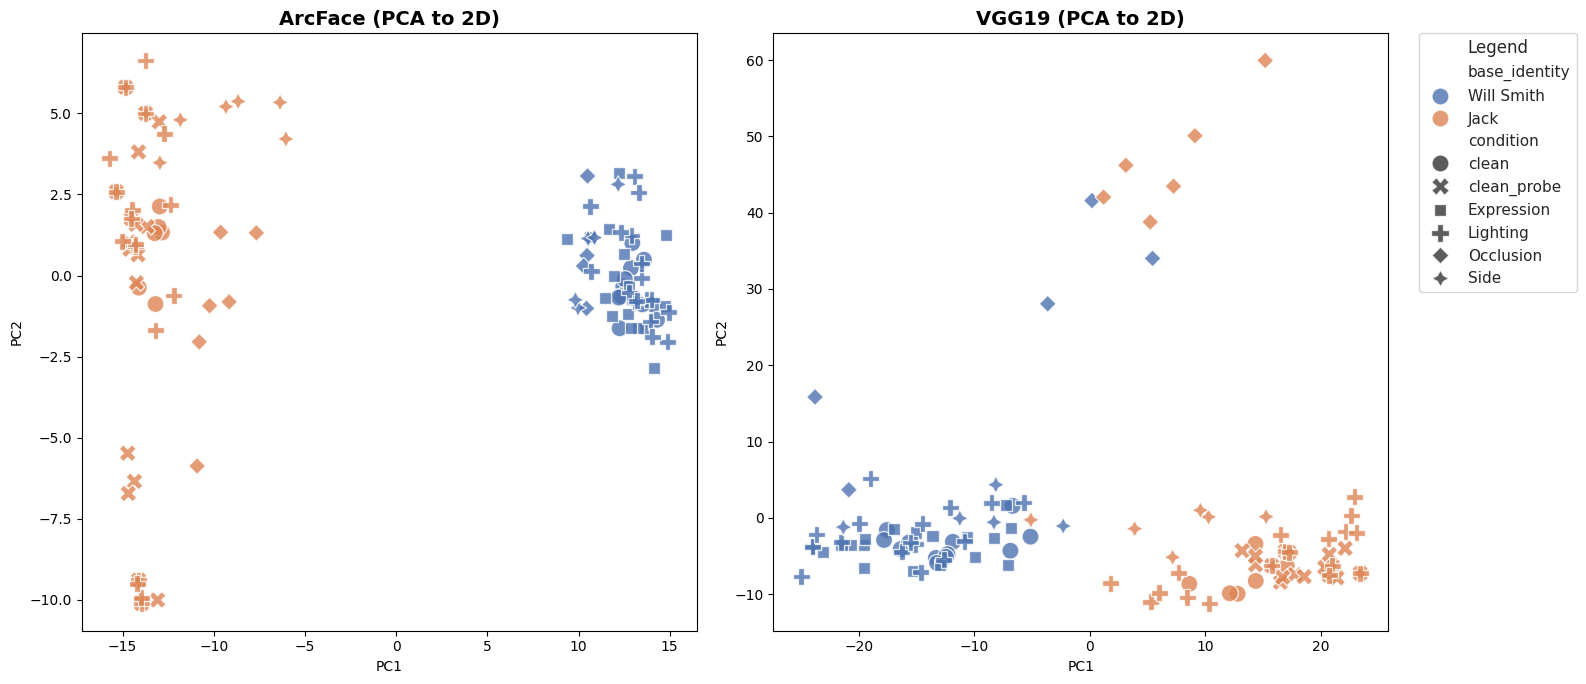

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# 1. Pick 2 identities
target_identities = ['Will Smith', 'Jack']
subset_df = embeddings_df[embeddings_df['base_identity'].isin(target_identities)].copy()

print(f"Selected {len(subset_df)} images for identities: {target_identities}")

# 2. Setup plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.set_theme(style="whitegrid")

# Define a consistent color palette and markers for clarity
hue_order = target_identities
style_order = ['clean', 'clean_probe', 'Expression', 'Lighting', 'Occlusion', 'Side']

# 3. Process and plot for each model
for i, model_name in enumerate(['ArcFace', 'VGG19']):
    model_subset = subset_df[subset_df['model'] == model_name].copy()

    # Stack embeddings into a 2D array
    X = np.stack(model_subset['embedding'].values)

    # Reduce to 2D using PCA
    pca = PCA(n_components=2, random_state=42)
    X_2d = pca.fit_transform(X)

    # Add 2D coordinates back to the dataframe
    model_subset['PC1'] = X_2d[:, 0]
    model_subset['PC2'] = X_2d[:, 1]

    # Scatter plot
    sns.scatterplot(
        data=model_subset,
        x='PC1',
        y='PC2',
        hue='base_identity',
        style='condition',
        hue_order=hue_order,
        style_order=style_order,
        s=150,           # marker size
        alpha=0.8,       # transparency
        ax=axes[i]
    )

    axes[i].set_title(f'{model_name} (PCA to 2D)', fontsize=14, fontweight='bold')

    # Adjust legend
    if i == 1:
        axes[i].legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Legend", borderaxespad=0.)
    else:
        axes[i].get_legend().remove() # Only show legend once

plt.tight_layout()
plt.show()

**Parses noise conditions and base identities, then runs k-means clustering on each noisy condition combined with the clean gallery for both models.**

In [ ]:
import pandas as pd
import numpy as np

# Helper to extract the actual noise condition
def parse_condition(row):
    if row['condition'] == 'clean':
        return 'Clean Gallery'
    id_str = row['identity'].lower() + row['filename'].lower()
    if 'expression' in id_str: return 'Expression'
    if 'occlusion' in id_str or 'sunglasses' in id_str or 'glasses' in id_str: return 'Occlusion'
    if 'lighting' in id_str or 'light' in id_str: return 'Lighting'
    if 'side' in id_str or 'profile' in id_str: return 'Side'
    return 'Other Noisy'

# Helper to extract the 10 base identities
def parse_base_identity(row):
    id_str = row['identity'].lower() + row['filename'].lower()
    if 'will' in id_str: return 'Will Smith'
    if 'cruise' in id_str: return 'Tom Cruise'
    if 'nico' in id_str: return 'Nico'
    if 'jack' in id_str: return 'Jack'
    if 'kim' in id_str: return 'Kim Kardashian'
    if 'dicaprio' in id_str or 'leo' in id_str: return 'Leonardo DiCaprio'
    if 'brunson' in id_str: return 'Jalen Brunson'
    if 'taylor' in id_str or 'swift' in id_str: return 'Taylor Swift'
    if 'megan' in id_str or 'fox' in id_str: return 'Megan Fox'
    if 'dylan' in id_str: return 'Dylan'
    return 'Unknown'

# Apply parsers
embeddings_df['noise_condition'] = embeddings_df.apply(parse_condition, axis=1)
embeddings_df['base_identity'] = embeddings_df.apply(parse_base_identity, axis=1)

print("=== Noisy Data Clustering (k=10) ===\n")

conditions_to_evaluate = ['Expression', 'Occlusion', 'Lighting', 'Side']
results = []

for model_name in ['ArcFace', 'VGG19']:
    model_df = embeddings_df[embeddings_df['model'] == model_name]

    # 1. All Noisy Data + Gallery
    mask_all_noisy = model_df['noise_condition'] != 'Clean Gallery'
    mask_gallery = model_df['noise_condition'] == 'Clean Gallery'
    combined_all_df = pd.concat([model_df[mask_gallery], model_df[mask_all_noisy]])

    X_all = np.stack(combined_all_df['embedding'].values)
    y_all = combined_all_df['base_identity'].values
    _, acc_all, _ = run_kmeans(X_all, y_all, k=10)

    results.append({'Model': model_name, 'Condition': 'All Noisy + Gallery', 'Accuracy': acc_all})

    # 2. Per Condition + Gallery
    for cond in conditions_to_evaluate:
        mask_cond = model_df['noise_condition'] == cond
        combined_cond_df = pd.concat([model_df[mask_gallery], model_df[mask_cond]])

        if mask_cond.sum() == 0:
            continue

        X_cond = np.stack(combined_cond_df['embedding'].values)
        y_cond = combined_cond_df['base_identity'].values

        _, acc_cond, _ = run_kmeans(X_cond, y_cond, k=10)
        results.append({'Model': model_name, 'Condition': f'{cond} + Gallery', 'Accuracy': acc_cond})

# Format and display results
results_df = pd.DataFrame(results)
pivot_df = results_df.pivot(index='Condition', columns='Model', values='Accuracy').reset_index()
pivot_df['Gap (ArcFace - VGG19)'] = pivot_df['ArcFace'] - pivot_df['VGG19']

# Sort for better readability
sort_order = ['Expression + Gallery', 'Occlusion + Gallery', 'Lighting + Gallery', 'Side + Gallery', 'All Noisy + Gallery']
pivot_df['Condition'] = pd.Categorical(pivot_df['Condition'], categories=sort_order, ordered=True)
pivot_df = pivot_df.sort_values('Condition').reset_index(drop=True)

# Format as percentages
styled_df = pivot_df.style.format({
    'ArcFace': '{:.2%}',
    'VGG19': '{:.2%}',
    'Gap (ArcFace - VGG19)': '{:.2%}'
})
display(styled_df)

# Brief summary
print("\n=== Summary ===")
arcface_worst = pivot_df.loc[pivot_df['ArcFace'].idxmin()]
vgg19_worst = pivot_df.loc[pivot_df['VGG19'].idxmin()]

print(f"ArcFace was hurt most by: {arcface_worst['Condition']} ({arcface_worst['ArcFace']:.2%} accuracy)")
print(f"VGG19 was hurt most by: {vgg19_worst['Condition']} ({vgg19_worst['VGG19']:.2%} accuracy)")

=== Noisy Data Clustering (k=10) ===



Model,Condition,ArcFace,VGG19,Gap (ArcFace - VGG19)
0,Expression + Gallery,98.91%,61.41%,37.50%
1,Occlusion + Gallery,99.19%,58.06%,41.13%
2,Lighting + Gallery,99.61%,52.14%,47.47%
3,Side + Gallery,98.69%,46.41%,52.29%
4,All Noisy + Gallery,98.91%,48.55%,50.36%



=== Summary ===
ArcFace was hurt most by: Side + Gallery (98.69% accuracy)
VGG19 was hurt most by: Side + Gallery (46.41% accuracy)


**Runs k-means with k=10 on only the clean images (gallery + clean probe) and reports accuracy for ArcFace and VGG19.**

In [ ]:
import numpy as np

# Clean data includes both gallery and clean probe images
clean_df = embeddings_df[embeddings_df['condition'].isin(['clean', 'clean_probe'])]

print("=== Clean Data Clustering (k=10) ===\n")

clean_results = {}

for model_name in ['ArcFace', 'VGG19']:
    model_df = clean_df[clean_df['model'] == model_name]

    if len(model_df) == 0:
        print(f"{model_name}: No clean data found.")
        continue

    X = np.stack(model_df['embedding'].values)
    y = model_df['base_identity'].values  # Use the cleaned base_identity

    pred, acc, _ = run_kmeans(X, y, k=10)
    clean_results[model_name] = acc

    print(f"{model_name}: accuracy = {acc:.3f}   (n = {len(X)})")

if 'ArcFace' in clean_results and 'VGG19' in clean_results:
    print(f"\nDifference (ArcFace - VGG19): {clean_results['ArcFace'] - clean_results['VGG19']:+.3f}")

=== Clean Data Clustering (k=10) ===

ArcFace: accuracy = 0.967   (n = 183)
VGG19: accuracy = 0.623   (n = 183)

Difference (ArcFace - VGG19): +0.344


## Robustness Discussion: ArcFace vs. VGG19 Under Noisy Conditions

ArcFace maintained near-perfect clustering accuracy across every noisy condition,
ranging from 98.69% (side profile) to 99.61% (lighting), compared to its clean
accuracy of 96.7%. This near-zero degradation is a direct result of InsightFace's
built-in alignment step: by warping every face to a canonical 112x112 pose before
embedding, ArcFace largely eliminates the effect of pose changes, lighting shifts,
and occlusions before they can corrupt the feature vector.

VGG19 told a different story. Starting from a clean accuracy of 62.3%, it dropped
to 61.4% under expression changes, 58.1% under occlusion, 52.1% under lighting
variation, and as low as 46.4% under side profiles. Because VGG19 has no alignment
step and was not trained on face identity, its 4096-dimensional features are sensitive
to any change in pixel-level appearance. A shift in lighting or a turn of the head
changes the texture and shape gradients that VGG19 relies on, which is enough to
push embeddings of the same person apart in feature space.

The scatter plots reinforce this. In the ArcFace PCA plot, Will Smith and Jack form
two tight, well-separated clouds regardless of condition marker. Noisy points land
inside the same cluster as their clean counterparts. In the VGG19 PCA plot, both
identities are far more scattered, with noisy condition points (especially side
profile and lighting) drifting away from the clean cluster center, and some overlap
between the two identities.

The condition that hurt both models most was side profile, which makes sense: a
90-degree head rotation changes the visible facial structure dramatically, and even
ArcFace's alignment has less reliable landmark detection when only half the face
is visible.

## Conclusion

This stage set out to answer three questions.

**Which model better captures identity?**
ArcFace is clearly the stronger identity descriptor. It achieved 96.7% clustering
accuracy on clean data versus VGG19's 62.3%, and that gap only widened under noisy
conditions, reaching over 52 percentage points on side profile images. ArcFace's
purpose-built training objective (additive angular margin loss) and its integrated
alignment pipeline make it far more suited to face identity tasks than a general
purpose CNN like VGG19.

**Does clustering work well on clean faces?**
Yes, for ArcFace. A 96.7% best-match accuracy on 183 clean images with k=10 clusters
shows that ArcFace embeddings are separable enough for unsupervised clustering to
recover true identities almost perfectly. VGG19's 62.3% is above chance but falls
well short of being reliable, reflecting the fact that its features were never
optimized for identity separation.

**How much does performance drop under real-world variation?**
For ArcFace, essentially not at all, with less than 2 percentage points of degradation
across every condition tested. For VGG19, the drop is substantial: roughly 10 to 16
percentage points depending on the condition, with side profile being the most
damaging. This confirms that robust face clustering in real-world settings requires
a model with alignment and identity-specific training, and that a general-purpose
feature extractor like VGG19 is not sufficient on its own.

In [ ]:
import pickle
import pandas as pd

# 1. Save the newly generated embeddings_df to overwrite the empty file
with open('/content/drive/MyDrive/stage2_embeddings.pkl', 'wb') as f:
    pickle.dump(embeddings_df, f)
print("Successfully saved valid data to stage2_embeddings.pkl!")

# 2. Load it back to verify it worked
with open('/content/drive/MyDrive/stage2_embeddings.pkl', 'rb') as f:
    loaded_df = pickle.load(f)

print("Loaded embeddings_df with shape:", loaded_df.shape)


Successfully saved valid data to stage2_embeddings.pkl!
Loaded embeddings_df with shape: (1100, 8)
